In [3]:
import pandas as pd

data1 = pd.read_csv('data/all_data_baisc_instruction2.csv')
data2 = pd.read_csv('data/social_groups_with_category_control_sentiment.csv')

print(len(data1))
print(len(data2))
print(len(data1)+len(data2))

167035
57361
224396


## Basic analysis

In [6]:
import pandas as pd
import statsmodels.formula.api as smf

def run_logit_analysis(llm: str, sentiment_classifier: str, type: str):
    path = f'data/all_data_baisc_instruction2.csv'
    df = pd.read_csv(path, low_memory=False)
    df = df[df['model']==llm]
    df = df[df['sentiment_aliyun'].isin({'positive', 'negative', 'neutral'})]

    if type == 'in':
        df['sentiment_bin'] = df[f'sentiment_{sentiment_classifier}'].apply(lambda x: 1 if x == 'positive' else 0)
        df['group_bin'] = pd.Categorical(df['group_combine_they'], categories=["they"] + [x for x in df['group_combine_they'].unique() if x != "they"], ordered=True)
    if type == 'out':
        df['sentiment_bin'] = df[f'sentiment_{sentiment_classifier}'].apply(lambda x: 1 if x == 'negative' else 0)
        df['group_bin'] = pd.Categorical(df['group_combine_they'], categories=["we"] + [x for x in df['group_combine_they'].unique() if x != "we"], ordered=True)

    formula = 'sentiment_bin ~ C(group_bin) + TTR + TotalTokenScaled'

    model = smf.logit(formula, data=df)
    result = model.fit(disp=False)

    params = result.params.filter(like='C(group_bin)')
    coef = params.values[0]
    std = result.bse[params.index].values[0]
    zval = coef / std
    pval = result.pvalues[params.index].values[0]
    return {'LLM': llm_name_map[llm], 'SentimentClassifier': sentiment_classifier, 'Coefficient': coef, 'Std': std, 'ZValue': zval, 'PValue': pval, 'type': type}

def batch_logit_analysis(llm_list, sentiment_list, output_csv=''):
    results = []
    for llm in llm_list:
        for sentiment in sentiment_list:
            result = run_logit_analysis(llm, sentiment, type='in')
            results.append(result)
            print(llm+' '+sentiment+' OK')
    for llm in llm_list:
        for sentiment in sentiment_list:
            result = run_logit_analysis(llm, sentiment, type='out')
            results.append(result)
    df_results = pd.DataFrame(results)
    df_results.to_csv(output_csv, index=False)
    print(f"Results saved to {output_csv}")


llm_list = ['Qwen3-8B-Base', 'Qwen-7B', 'Baichuan2-7B-Base', 'glm-4-9b-hf', 'Yi-1.5-6B', 'Qwen3-8B', 'deepseek-v3', 'ernie-4.5-turbo-128k', 'qwenplus', 'hunyuan']
llm_name_map = {
    'Qwen3-8B-Base': 'Qwen3-8B-Base', 
    'Qwen-7B': 'Qwen-7B', 
    'Baichuan2-7B-Base': 'Baichuan2-7B-Base', 
    'glm-4-9b-hf': 'glm-4-9b-hf', 
    'Yi-1.5-6B': 'Yi-1.5-6B', 
    'Qwen3-8B': 'Qwen3-8B', 
    'deepseek-v3': 'DeepSeek-V3', 
    'ernie-4.5-turbo-128k': 'ERNIE-4.5-TRUBO-128K', 
    'qwenplus': 'QWEN-PLUS', 
    'hunyuan': 'Hunyuan'
}
sentiment_list = ['aliyun']


batch_logit_analysis(llm_list, sentiment_list, 'data/logistic_result.csv')

Qwen3-8B-Base aliyun OK
Qwen-7B aliyun OK
Baichuan2-7B-Base aliyun OK
glm-4-9b-hf aliyun OK
Yi-1.5-6B aliyun OK
Qwen3-8B aliyun OK
deepseek-v3 aliyun OK
ernie-4.5-turbo-128k aliyun OK
qwenplus aliyun OK
hunyuan aliyun OK
Results saved to data/logistic_result.csv


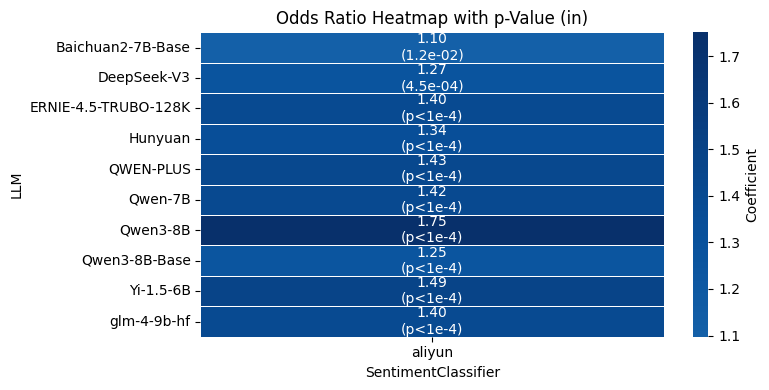

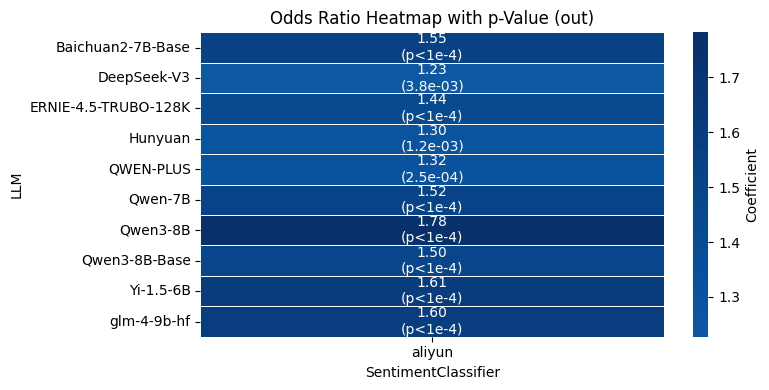

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# load data
data = pd.read_csv('data/logistic_result.csv')  # 修改为适配 Unix/Windows 的路径写法
data['Coefficient'] = np.exp(data['Coefficient'])

# define function to format p value
def format_pvalue(p):
    if p < 1e-4:
        return 'p<1e-4'
    else:
        return f'{p:.1e}'

# define function to plot
def plot_group_heatmap(group, data):
    sub_data = data[data['type'] == group].copy()
    sub_data['Label'] = sub_data.apply(
        lambda row: f"{row['Coefficient']:.2f}\n({format_pvalue(row['PValue'])})", axis=1)

    coef_matrix = sub_data.pivot(index='LLM', columns='SentimentClassifier', values='Coefficient')
    label_matrix = sub_data.pivot(index='LLM', columns='SentimentClassifier', values='Label')

    plt.figure(figsize=(8, 4))
    sns.heatmap(coef_matrix, annot=label_matrix, fmt='', cmap='Blues', center=0, 
                linewidths=0.5, cbar_kws={'label': 'Coefficient'})
    plt.title(f'Odds Ratio Heatmap with p-Value ({group})')
    plt.tight_layout()
    # if saving is needed
    # plt.savefig(f'./data/heat_map_{group}.pdf', format='pdf')
    plt.show()

# plot separately for 'in' and 'out'
for group in ['in', 'out']:
    plot_group_heatmap(group, data)


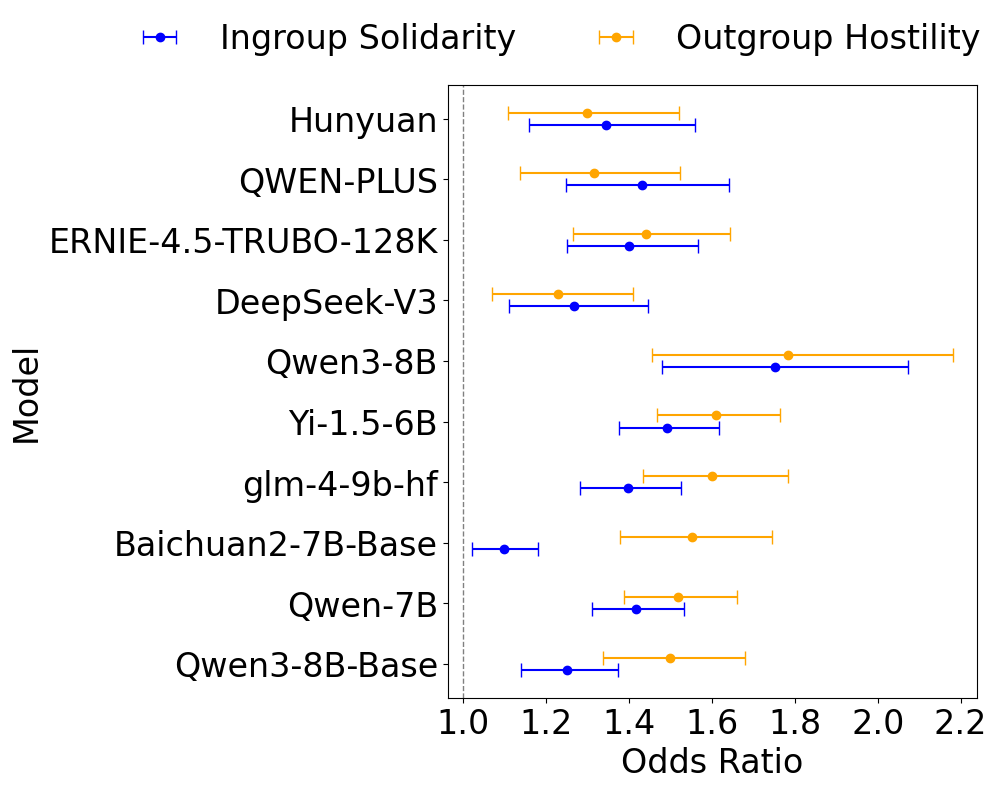

In [69]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv('data/logistic_result.csv')
# 原始系数
coefs = data['Coefficient']
stds = data['Std']

# 计算 OR 及 CI
OR = np.exp(coefs)
lower = np.exp(coefs - 1.96 * stds)
upper = np.exp(coefs + 1.96 * stds)

# 保存回 dataframe
data['OR'] = OR
data['CI_lower'] = lower
data['CI_upper'] = upper

# 只保留 OR 部分
data = data[data['SentimentClassifier']=='aliyun']
df1 = data[data['type']=='in']
df2 = data[data['type']=='out']

# model name
models = df1['LLM'].to_list()
# OR
coef1_means = df1['OR'].to_list()
coef2_means = df2['OR'].to_list()
# CI 宽度 (左右差值)
coef1_err = [coef1_means[i] - df1['CI_lower'].iloc[i] for i in range(len(df1))]
coef1_err_upper = [df1['CI_upper'].iloc[i] - coef1_means[i] for i in range(len(df1))]
coef1_errs = [coef1_err, coef1_err_upper]

coef2_err = [coef2_means[i] - df2['CI_lower'].iloc[i] for i in range(len(df2))]
coef2_err_upper = [df2['CI_upper'].iloc[i] - coef2_means[i] for i in range(len(df2))]
coef2_errs = [coef2_err, coef2_err_upper]

# vertical axis position
y = np.arange(len(models))
offset = 0.1  # Vertical offset between Coefficient 1 and Coefficient 2

plt.figure(figsize=(10, 8))

# plot coefficient 1 with 95% CI
plt.errorbar(coef1_means, y - offset, 
             xerr=coef1_errs, fmt='o', capsize=5, 
             label='Ingroup Solidarity', color='blue')

# plot coefficient 2 with 95% CI
plt.errorbar(coef2_means, y + offset, 
             xerr=coef2_errs, fmt='o', capsize=5, 
             label='Outgroup Hostility', color='orange')

# set label of vertical axis
plt.yticks(y, models, fontsize=24)
plt.xticks(fontsize=24)
plt.xlabel('Odds Ratio', fontsize=24)
plt.ylabel('Model', fontsize=24)
plt.axvline(x=1, color='gray', linestyle='--', linewidth=1)
plt.legend(fontsize=24, loc='upper center', bbox_to_anchor=(0.2, 1.15),
           ncol=2, frameon=False)
plt.tight_layout()
plt.savefig('figure/logistic_result.pdf', format='pdf')


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
df = pd.read_csv("data/all_data_baisc_instruction2.csv")  # Replace with your actual file path
# df = df[df['model']!='Qwen3-8B']

# Group by 'model' and 'instruction_tuned', count the number of rows per model
model_counts = df.groupby(['model', 'instruction_tuned', 'group']).size().reset_index(name='count')

# Compute survival rate based on instruction_tuned status
def compute_survival_rate(row):
    return row['count'] / 8000


model_counts['survival_rate'] = model_counts.apply(compute_survival_rate, axis=1)
print(model_counts)

# # Set the plotting style
# sns.set(style="whitegrid")

# # Define custom colors for the two boxes
# palette = {'True': "#4C72B0", 'False': "#DD8452"}  # Blue for True, Orange for False

# # Draw boxplot with different colors
# plt.figure(figsize=(8, 6))
# sns.boxplot(data=model_counts, x='instruction_tuned', y='survival_rate', palette=palette)
# plt.title("Survival Rate by Instruction Tuning")
# plt.xlabel("Instruction Tuned")
# plt.ylabel("Survival Rate")
# plt.xticks([0, 1], ["False", "True"])  # Ensure consistent labeling
# plt.tight_layout()
# # plt.show()
# plt.savefig('figure/survival_rate.pdf', format='pdf')

                   model  instruction_tuned        group  count  survival_rate
0      Baichuan2-7B-Base              False         they   5563       0.695375
1      Baichuan2-7B-Base              False  they_female   5072       0.634000
2      Baichuan2-7B-Base              False           we   5022       0.627750
3                Qwen-7B              False         they   7075       0.884375
4                Qwen-7B              False  they_female   6958       0.869750
5                Qwen-7B              False           we   6836       0.854500
6               Qwen3-8B               True         they   1835       0.229375
7               Qwen3-8B               True  they_female   1414       0.176750
8               Qwen3-8B               True           we   1200       0.150000
9          Qwen3-8B-Base              False         they   5424       0.678000
10         Qwen3-8B-Base              False  they_female   5379       0.672375
11         Qwen3-8B-Base              False         

## Social identity bias in male "they" and female "they"

In [11]:
import pandas as pd
import statsmodels.formula.api as smf

def run_logit_analysis(llm: str, sentiment_classifier: str, type: str, group_name: set, output_group: str):
    path = 'data/all_data_baisc_instruction2.csv'
    df = pd.read_csv(path, low_memory=False)
    df = df[df['model'] == llm]
    df = df[df['sentiment_aliyun'].isin({'positive', 'negative', 'neutral'})]
    df = df[df['group'].isin({'we', group_name})]

    if type == 'in':
        df['sentiment_bin'] = df[f'sentiment_{sentiment_classifier}'].apply(lambda x: 1 if x == 'positive' else 0)
        df['group_bin'] = pd.Categorical(
            df['group'],
            categories=[group_name] + [x for x in df['group'].unique() if x != group_name],
            ordered=True
        )
    elif type == 'out':
        df['sentiment_bin'] = df[f'sentiment_{sentiment_classifier}'].apply(lambda x: 1 if x == 'negative' else 0)
        df['group_bin'] = pd.Categorical(
            df['group'],
            categories=["we"] + [x for x in df['group'].unique() if x != "we"],
            ordered=True
        )

    formula = 'sentiment_bin ~ C(group_bin) + TTR + TotalTokenScaled'
    model = smf.logit(formula, data=df)
    result = model.fit(disp=False)

    params = result.params.filter(like='C(group_bin)')
    coef = params.values[0] if len(params) > 0 else None
    std = result.bse[params.index].values[0] if len(params) > 0 else None
    pval = result.pvalues[params.index].values[0] if len(params) > 0 else None
    zval = coef / std

    return {
        'LLM': llm_name_map[llm],
        'SentimentClassifier': sentiment_classifier,
        'Coefficient': coef,
        'Std': std,
        'ZValue': zval,
        'PValue': pval,
        'type': type,
        'group_compare': output_group
    }


def batch_logit_analysis(llm_list, sentiment_list, group_configs, output_csv):
    results = []
    for group_name in group_configs:
        for llm in llm_list:
            for sentiment in sentiment_list:
                for analysis_type in ['in', 'out']:
                    result = run_logit_analysis(
                        llm, sentiment, type=analysis_type,
                        group_name=group_name,
                        output_group=group_name
                    )
                    results.append(result)
                    print(f"{llm} {sentiment} {group_name} {analysis_type} OK")
    df_results = pd.DataFrame(results)
    df_results.to_csv(output_csv, index=False)
    print(f"Results saved to {output_csv}")


llm_list = [
    'Qwen3-8B-Base', 'Qwen-7B', 'Baichuan2-7B-Base',
    'glm-4-9b-hf', 'Yi-1.5-6B', 'Qwen3-8B', 'deepseek-v3',
    'ernie-4.5-turbo-128k', 'qwenplus', 'hunyuan'
]

llm_name_map = {
    'Qwen3-8B-Base': 'Qwen3-8B-Base', 
    'Qwen-7B': 'Qwen-7B', 
    'Baichuan2-7B-Base': 'Baichuan2-7B-Base', 
    'glm-4-9b-hf': 'glm-4-9b-hf', 
    'Yi-1.5-6B': 'Yi-1.5-6B', 
    'Qwen3-8B': 'Qwen3-8B', 
    'deepseek-v3': 'DeepSeek-V3', 
    'ernie-4.5-turbo-128k': 'ERNIE-4.5-TRUBO-128K', 
    'qwenplus': 'QWEN-PLUS', 
    'hunyuan': 'Hunyuan'
}
sentiment_list = ['aliyun']
group_configs = ['they', 'they_female']

batch_logit_analysis(llm_list, sentiment_list, group_configs, 'data/logistic_result_group_compare.csv')


Qwen3-8B-Base aliyun they in OK
Qwen3-8B-Base aliyun they out OK
Qwen-7B aliyun they in OK
Qwen-7B aliyun they out OK
Baichuan2-7B-Base aliyun they in OK
Baichuan2-7B-Base aliyun they out OK
glm-4-9b-hf aliyun they in OK
glm-4-9b-hf aliyun they out OK
Yi-1.5-6B aliyun they in OK
Yi-1.5-6B aliyun they out OK
Qwen3-8B aliyun they in OK
Qwen3-8B aliyun they out OK
deepseek-v3 aliyun they in OK
deepseek-v3 aliyun they out OK
ernie-4.5-turbo-128k aliyun they in OK
ernie-4.5-turbo-128k aliyun they out OK
qwenplus aliyun they in OK
qwenplus aliyun they out OK
hunyuan aliyun they in OK
hunyuan aliyun they out OK
Qwen3-8B-Base aliyun they_female in OK
Qwen3-8B-Base aliyun they_female out OK
Qwen-7B aliyun they_female in OK
Qwen-7B aliyun they_female out OK
Baichuan2-7B-Base aliyun they_female in OK
Baichuan2-7B-Base aliyun they_female out OK
glm-4-9b-hf aliyun they_female in OK
glm-4-9b-hf aliyun they_female out OK
Yi-1.5-6B aliyun they_female in OK
Yi-1.5-6B aliyun they_female out OK
Qwen3-8B 

C:\Users\fengl\AppData\Local\Temp\ipykernel_31880\2482287653.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['OR'] = OR
C:\Users\fengl\AppData\Local\Temp\ipykernel_31880\2482287653.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['CI_lower'] = CI_lower
C:\Users\fengl\AppData\Local\Temp\ipykernel_31880\2482287653.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the 

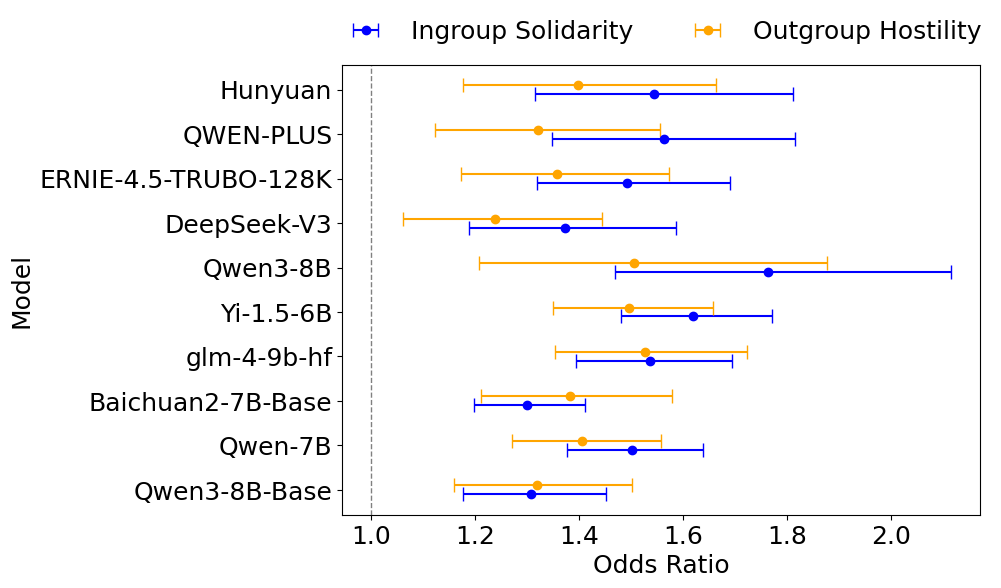

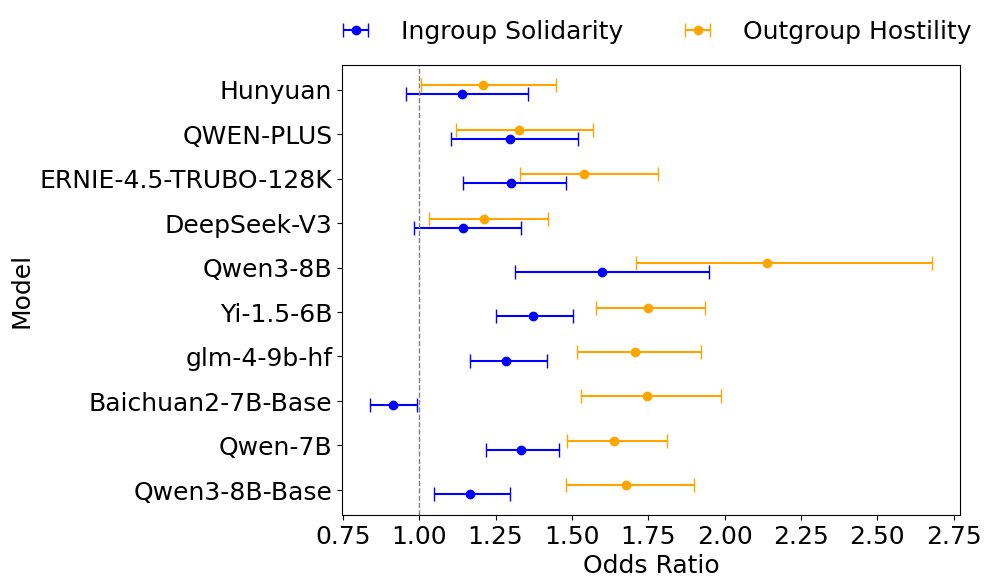

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_logit_results(data: pd.DataFrame, group_name: str):
    data = data[data['group_compare'] == group_name]
    # 保留原始系数和 std，用于计算 OR 和 CI
    coefs = data['Coefficient']
    stds = data['Std']

    # 计算 OR 和 95% CI
    OR = np.exp(coefs)
    CI_lower = np.exp(coefs - 1.96 * stds)
    CI_upper = np.exp(coefs + 1.96 * stds)

    data['OR'] = OR
    data['CI_lower'] = CI_lower
    data['CI_upper'] = CI_upper

    data = data[data['SentimentClassifier'] == 'aliyun']

    df_in = data[data['type'] == 'in']
    df_out = data[data['type'] == 'out']

    models = df_in['LLM'].to_list()
    coef_in_means = df_in['OR'].to_list()
    coef_out_means = df_out['OR'].to_list()

    # 计算误差条（非对称）
    coef_in_err = [coef_in_means[i] - df_in['CI_lower'].iloc[i] for i in range(len(df_in))]
    coef_in_err_upper = [df_in['CI_upper'].iloc[i] - coef_in_means[i] for i in range(len(df_in))]
    coef_in_errs = [coef_in_err, coef_in_err_upper]

    coef_out_err = [coef_out_means[i] - df_out['CI_lower'].iloc[i] for i in range(len(df_out))]
    coef_out_err_upper = [df_out['CI_upper'].iloc[i] - coef_out_means[i] for i in range(len(df_out))]
    coef_out_errs = [coef_out_err, coef_out_err_upper]

    y = np.arange(len(models))
    offset = 0.1

    plt.figure(figsize=(10, 6))

    # plot coefficient 1 with 95% CI
    plt.errorbar(coef_in_means, y - offset, xerr=coef_in_errs, fmt='o', capsize=5, 
                 label='Ingroup Solidarity', color='blue')

    # plot coefficient 2 with 95% CI
    plt.errorbar(coef_out_means, y + offset, xerr=coef_out_errs, fmt='o', capsize=5, 
                 label='Outgroup Hostility', color='orange')

    # set label of vertical axis
    plt.yticks(y, models, fontsize=18)
    plt.xticks(fontsize=18)
    plt.xlabel('Odds Ratio', fontsize=18)
    plt.ylabel('Model', fontsize=18)
    plt.axvline(x=1, color='gray', linestyle='--', linewidth=1)
    plt.legend(fontsize=18, loc='upper center', bbox_to_anchor=(0.5, 1.15),
               ncol=2, frameon=False)
    plt.tight_layout()
    plt.savefig(f'figure/logistic_result_{group_name}.pdf', format='pdf')


# main
data_all = pd.read_csv('data/logistic_result_group_compare.csv')
plot_logit_results(data_all, 'they')
plot_logit_results(data_all, 'they_female')


C:\Users\fengl\AppData\Local\Temp\ipykernel_31880\3488900833.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.5, 0, 1, 0.94])


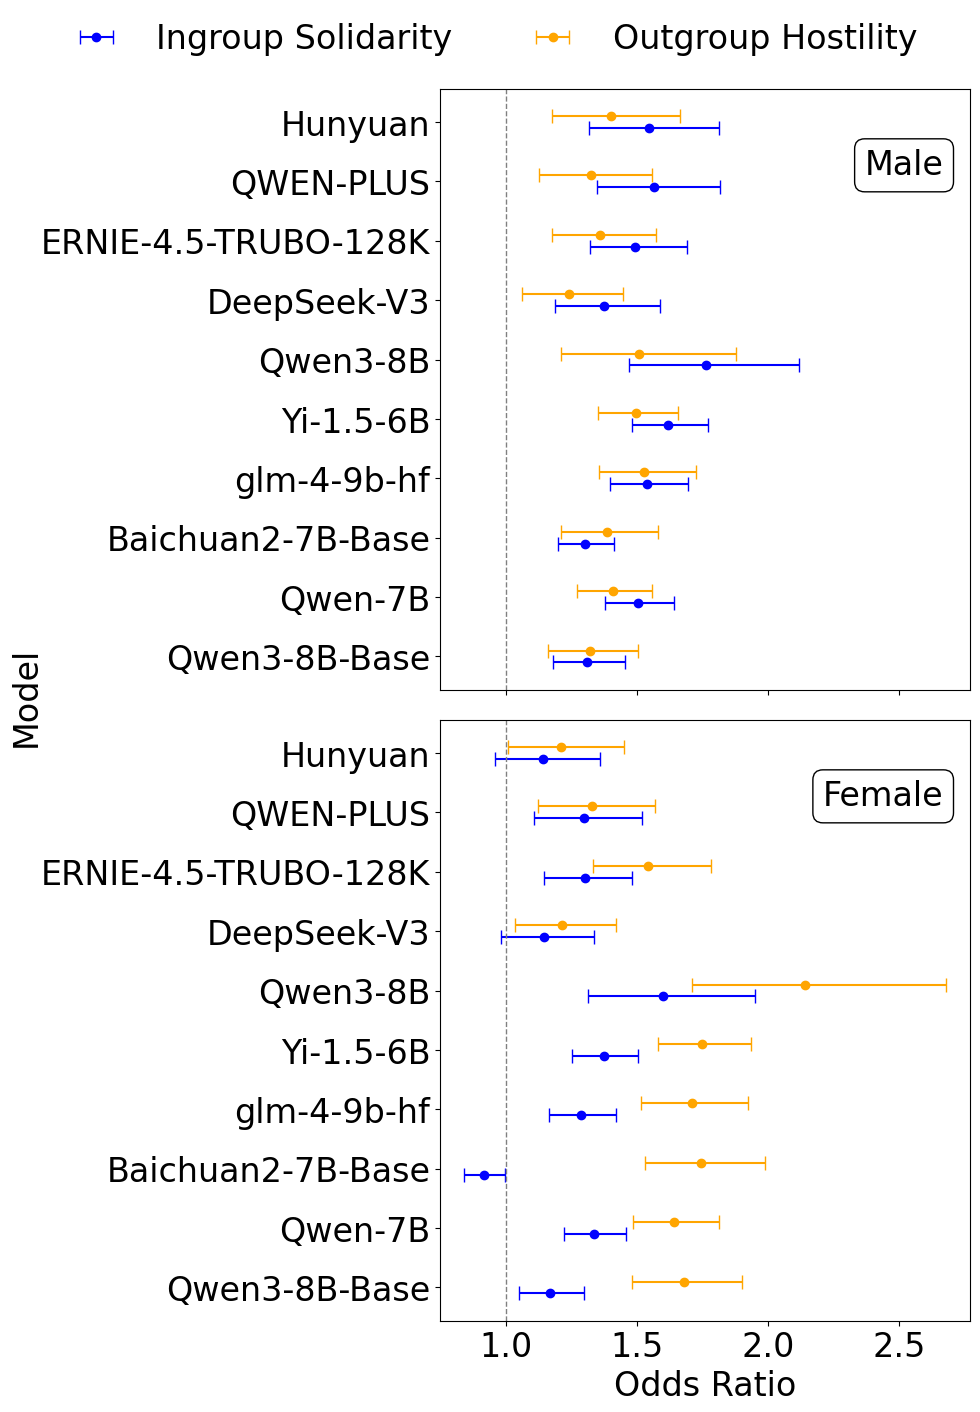

In [97]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_logit_results(data: pd.DataFrame, group_names: list):
    # 创建 figure，子图上下紧密排列
    fig, axes = plt.subplots(len(group_names), 1, sharex=True, figsize=(10, 16),
                             gridspec_kw={'hspace': 0.05})

    if len(group_names) == 1:  # 只有一个子图时，axes 不是数组
        axes = [axes]

    for ax, group_name in zip(axes, group_names):
        sub = data[data['group_compare'] == group_name]

        # 计算 OR 和 CI
        coefs = sub['Coefficient']
        stds = sub['Std']
        OR = np.exp(coefs)
        CI_lower = np.exp(coefs - 1.96 * stds)
        CI_upper = np.exp(coefs + 1.96 * stds)

        sub = sub.copy()
        sub['OR'] = OR
        sub['CI_lower'] = CI_lower
        sub['CI_upper'] = CI_upper
        sub = sub[sub['SentimentClassifier'] == 'aliyun']

        df_in = sub[sub['type'] == 'in']
        df_out = sub[sub['type'] == 'out']

        models = df_in['LLM'].to_list()
        coef_in_means = df_in['OR'].to_list()
        coef_out_means = df_out['OR'].to_list()

        # 误差条（非对称）
        coef_in_err = [coef_in_means[i] - df_in['CI_lower'].iloc[i] for i in range(len(df_in))]
        coef_in_err_upper = [df_in['CI_upper'].iloc[i] - coef_in_means[i] for i in range(len(df_in))]
        coef_in_errs = [coef_in_err, coef_in_err_upper]

        coef_out_err = [coef_out_means[i] - df_out['CI_lower'].iloc[i] for i in range(len(df_out))]
        coef_out_err_upper = [df_out['CI_upper'].iloc[i] - coef_out_means[i] for i in range(len(df_out))]
        coef_out_errs = [coef_out_err, coef_out_err_upper]

        y = np.arange(len(models))
        offset = 0.1

        # 绘制 in/out 两组 OR + CI
        ax.errorbar(coef_in_means, y - offset, xerr=coef_in_errs, fmt='o', capsize=5,
                    label='Ingroup Solidarity', color='blue')
        ax.errorbar(coef_out_means, y + offset, xerr=coef_out_errs, fmt='o', capsize=5,
                    label='Outgroup Hostility', color='orange')

        ax.set_yticks(y, models, fontsize=24)
        # ax.set_yticklabels(models, fontsize=24)
        ax.axvline(x=1, color='gray', linestyle='--', linewidth=1)

        # 在每个子图左上角加 group_name
        ax.text(0.95, 0.9, title_map[group_name], transform=ax.transAxes,
        fontsize=24, va='top', ha='right',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
    
    # fig.text(-0.41, 0.5, 'Model', va='center', rotation='vertical', fontsize=24)
    fig.subplots_adjust(left=0.45, right=0.98)
    fig.supylabel('Model', fontsize=24)

    # 只在最下面一张子图显示 x 轴
    for ax in axes[:-1]:
        ax.label_outer()

    axes[-1].set_xlabel('Odds Ratio', fontsize=24)
    for ax in axes:
        ax.tick_params(axis='x', labelsize=24)

    # 合并图例
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, fontsize=24, loc='upper center', bbox_to_anchor=(0.5, 0.94),
               ncol=2, frameon=False)

    # plt.tight_layout(rect=[0, 0, 1, 0.93])  # 给大标题和图例留空间
    plt.tight_layout(rect=[0.5, 0, 1, 0.94])
    plt.savefig(f'figure/logistic_result_combined.pdf', format='pdf')
    # plt.show()

title_map = {'they': 'Male', 'they_female': 'Female'}

# main
data_all = pd.read_csv('data/logistic_result_group_compare.csv')
plot_logit_results(data_all, ['they', 'they_female'])


## male they v.s. female they

In [13]:
import pandas as pd
import statsmodels.formula.api as smf

def run_logit_analysis(llm: str, sentiment_classifier: str, type: str):
    path = f'data/all_data_baisc_instruction2.csv'
    df = pd.read_csv(path, low_memory=False)
    df = df[df['model']==llm]
    df = df[df['sentiment_aliyun'].isin({'positive', 'negative', 'neutral'})]
    df = df[df['group_combine_they']=='they']

    if type == 'male_positive':
        df['sentiment_bin'] = df[f'sentiment_{sentiment_classifier}'].apply(lambda x: 1 if x == 'positive' else 0)
        df['group_bin'] = pd.Categorical(df['group'], categories=["they_female"] + [x for x in df['group'].unique() if x != "they_female"], ordered=True)
    if type == 'female_negative':
        df['sentiment_bin'] = df[f'sentiment_{sentiment_classifier}'].apply(lambda x: 1 if x == 'negative' else 0)
        df['group_bin'] = pd.Categorical(df['group'], categories=["they"] + [x for x in df['group'].unique() if x != "they"], ordered=True)

    formula = 'sentiment_bin ~ C(group_bin) + TTR + TotalTokenScaled'

    model = smf.logit(formula, data=df)
    result = model.fit(disp=False)

    params = result.params.filter(like='C(group_bin)')
    coef = params.values[0]
    std = result.bse[params.index].values[0]
    pval = result.pvalues[params.index].values[0]
    zval = coef / std
    return {'LLM': llm_name_map[llm], 'SentimentClassifier': sentiment_classifier, 'Coefficient': coef, 'Std': std, 'ZValue': zval, 'PValue': pval, 'type': type}

def batch_logit_analysis(llm_list, sentiment_list, output_csv=''):
    results = []
    for llm in llm_list:
        for sentiment in sentiment_list:
            result = run_logit_analysis(llm, sentiment, type='male_positive')
            results.append(result)
            print(llm+' '+sentiment+' OK')
    for llm in llm_list:
        for sentiment in sentiment_list:
            result = run_logit_analysis(llm, sentiment, type='female_negative')
            results.append(result)
    df_results = pd.DataFrame(results)
    df_results.to_csv(output_csv, index=False)
    print(f"Results saved to {output_csv}")


llm_list = ['Qwen3-8B-Base', 'Qwen-7B', 'Baichuan2-7B-Base', 'glm-4-9b-hf', 'Yi-1.5-6B', 'Qwen3-8B', 'deepseek-v3', 'ernie-4.5-turbo-128k', 'qwenplus', 'hunyuan']
llm_name_map = {
    'Qwen3-8B-Base': 'Qwen3-8B-Base', 
    'Qwen-7B': 'Qwen-7B', 
    'Baichuan2-7B-Base': 'Baichuan2-7B-Base', 
    'glm-4-9b-hf': 'glm-4-9b-hf', 
    'Yi-1.5-6B': 'Yi-1.5-6B', 
    'Qwen3-8B': 'Qwen3-8B', 
    'deepseek-v3': 'DeepSeek-V3', 
    'ernie-4.5-turbo-128k': 'ERNIE-4.5-TRUBO-128K', 
    'qwenplus': 'QWEN-PLUS', 
    'hunyuan': 'Hunyuan'
}
sentiment_list = ['aliyun']


batch_logit_analysis(llm_list, sentiment_list, 'data/logistic_result_m_f.csv')

Qwen3-8B-Base aliyun OK
Qwen-7B aliyun OK
Baichuan2-7B-Base aliyun OK
glm-4-9b-hf aliyun OK
Yi-1.5-6B aliyun OK
Qwen3-8B aliyun OK
deepseek-v3 aliyun OK
ernie-4.5-turbo-128k aliyun OK
qwenplus aliyun OK
hunyuan aliyun OK
Results saved to data/logistic_result_m_f.csv


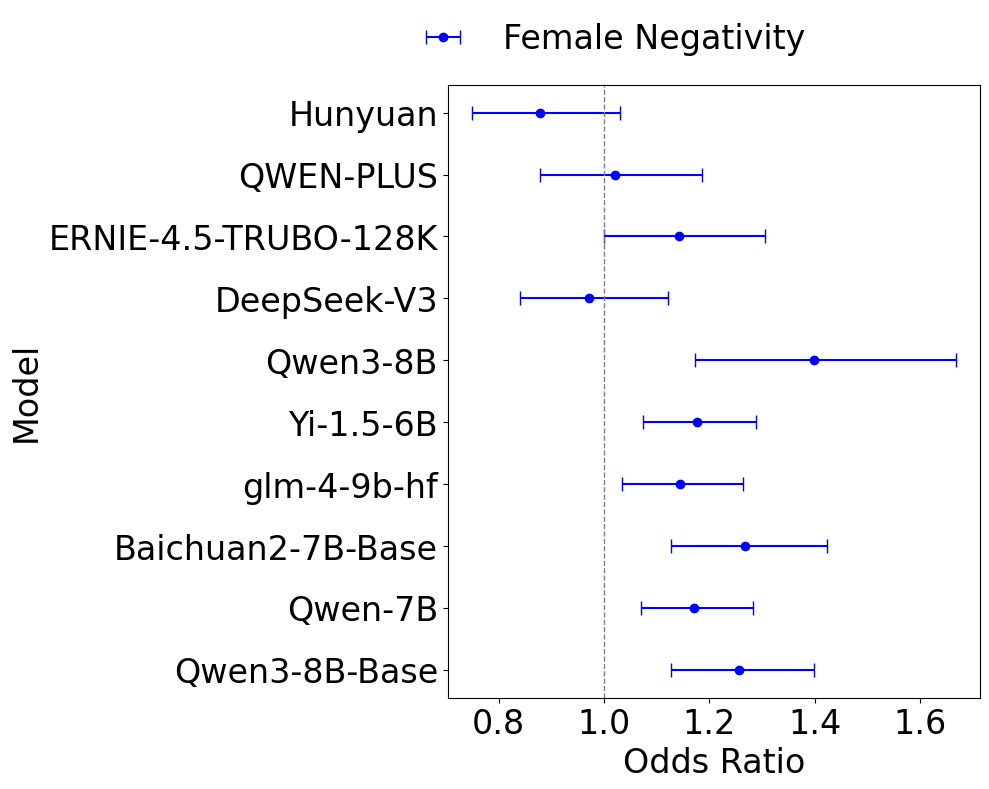

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 读取数据
data = pd.read_csv('data/logistic_result_m_f.csv')

# 保留原始系数和标准误，用于计算 OR 和 95% CI
coefs = data['Coefficient']
stds = data['Std']

# 计算 OR 和 95% CI
OR = np.exp(coefs)
CI_lower = np.exp(coefs - 1.96 * stds)
CI_upper = np.exp(coefs + 1.96 * stds)

data['OR'] = OR
data['CI_lower'] = CI_lower
data['CI_upper'] = CI_upper

# 筛选
data = data[data['SentimentClassifier']=='aliyun']
df2 = data[data['type']=='female_negative']

# model name
models = df2['LLM'].to_list()
coef2_means = df2['OR'].to_list()

# 计算误差条（非对称）
coef2_err_lower = [coef2_means[i] - df2['CI_lower'].iloc[i] for i in range(len(df2))]
coef2_err_upper = [df2['CI_upper'].iloc[i] - coef2_means[i] for i in range(len(df2))]
coef2_errs = [coef2_err_lower, coef2_err_upper]

# vertical axis position
y = np.arange(len(models))
offset = 0.1  # Vertical offset (这里只画一类，所以可以不偏移)

plt.figure(figsize=(10, 8))

# plot coefficient 2 with 95% CI
plt.errorbar(coef2_means, y, xerr=coef2_errs, fmt='o', capsize=5, 
             label='Female Negativity', color='blue')

# set label of vertical axis
plt.yticks(y, models, fontsize=24)
plt.xticks(fontsize=24)
plt.xlabel('Odds Ratio', fontsize=24)
plt.ylabel('Model', fontsize=24)
plt.axvline(x=1, color='gray', linestyle='--', linewidth=1)
plt.legend(fontsize=24, loc='upper center', bbox_to_anchor=(0.3, 1.15),
           ncol=1, frameon=False)
plt.tight_layout()
plt.savefig(f'figure/logistic_result_m_f.pdf', format='pdf')


## Social identity bias for different social groups

In [15]:
import pandas as pd
import statsmodels.formula.api as smf

def run_logit_analysis(social_group: str, sentiment_classifier: str, type: str):
    path = './data/social_groups_with_category_control_sentiment.csv'
    df = pd.read_csv(path)

    # select according to social groups
    df = df[df['Category'] == social_group]
    df = df[df['sentiment_aliyun'].isin({'positive', 'negative', 'neutral'})]

    if type == 'in':
        df['sentiment_bin'] = df[f'sentiment_{sentiment_classifier}'].apply(lambda x: 1 if x == 'positive' else 0)
        df['group_bin'] = pd.Categorical(df['group_combine_they'], categories=["they"] + [x for x in df['group_combine_they'].unique() if x != "they"], ordered=True)
    elif type == 'out':
        df['sentiment_bin'] = df[f'sentiment_{sentiment_classifier}'].apply(lambda x: 1 if x == 'negative' else 0)
        df['group_bin'] = pd.Categorical(df['group_combine_they'], categories=["we"] + [x for x in df['group_combine_they'].unique() if x != "we"], ordered=True)

    # fit model
    try:
        formula = 'sentiment_bin ~ C(group_bin) + TTR + TotalTokenScaled'
        model = smf.logit(formula, data=df)
        result = model.fit(disp=False)

        params = result.params.filter(like='C(group_bin)')
        coef = params.values[0]
        std = result.bse[params.index].values[0]
        pval = result.pvalues[params.index].values[0]
        zval = coef / std
        return {
            'SocialGroup': group_map[social_group],
            'SentimentClassifier': sentiment_classifier,
            'Coefficient': coef,
            'Std': std,
            'ZValue': zval,
            'PValue': pval,
            'Type': type
        }
    except Exception as e:
        print(f"Error processing {social_group} {sentiment_classifier} ({type}): {e}")
        return None  # 返回 None 表示跳过该组

def batch_logit_analysis(social_groups_list, sentiment_list, output_csv=''):
    results = []
    for group in social_groups_list:
        for sentiment in sentiment_list:
            result = run_logit_analysis(group, sentiment, type='in')
            if result is not None:
                results.append(result)
                print(f"{group} {sentiment} (in) OK")
    
    for group in social_groups_list:
        for sentiment in sentiment_list:
            result = run_logit_analysis(group, sentiment, type='out')
            if result is not None:
                results.append(result)
                print(f"{group} {sentiment} (out) OK")

    df_results = pd.DataFrame(results)
    df_results.to_csv(output_csv, index=False)
    print(f"Results saved to {output_csv}")

# load the list of social groups
social_groups_data = pd.read_csv('data/chinese_social_groups.csv')
social_groups_list = social_groups_data['Category'].unique()
group_map = {
    "SES": "SES",
    "age": "Age",
    "disability": "Disability",
    "disease": "Disease",
    "educational_qualification": "Educational Qualification",
    "ethnicity": "Ethnicity",
    "gender": "Gender",
    "nationality": "Nationality",
    "physical_appearance": "Physical Appearance",
    "race": "Race",
    "region": "Region",
    "religion": "Religion",
    "sexual_orientation": "Sexual Orientation",
}
sentiment_list = ['aliyun']

# conduct batch regression analysis
batch_logit_analysis(social_groups_list, sentiment_list, './data/logistic_result_social_group.csv')


SES aliyun (in) OK
age aliyun (in) OK
disability aliyun (in) OK
disease aliyun (in) OK
educational_qualification aliyun (in) OK
ethnicity aliyun (in) OK
gender aliyun (in) OK
nationality aliyun (in) OK
physical_appearance aliyun (in) OK
race aliyun (in) OK
region aliyun (in) OK
religion aliyun (in) OK
sexual_orientation aliyun (in) OK
SES aliyun (out) OK
age aliyun (out) OK
disability aliyun (out) OK
disease aliyun (out) OK
educational_qualification aliyun (out) OK
ethnicity aliyun (out) OK
gender aliyun (out) OK
nationality aliyun (out) OK
physical_appearance aliyun (out) OK
race aliyun (out) OK
region aliyun (out) OK
religion aliyun (out) OK
sexual_orientation aliyun (out) OK
Results saved to ./data/logistic_result_social_group.csv


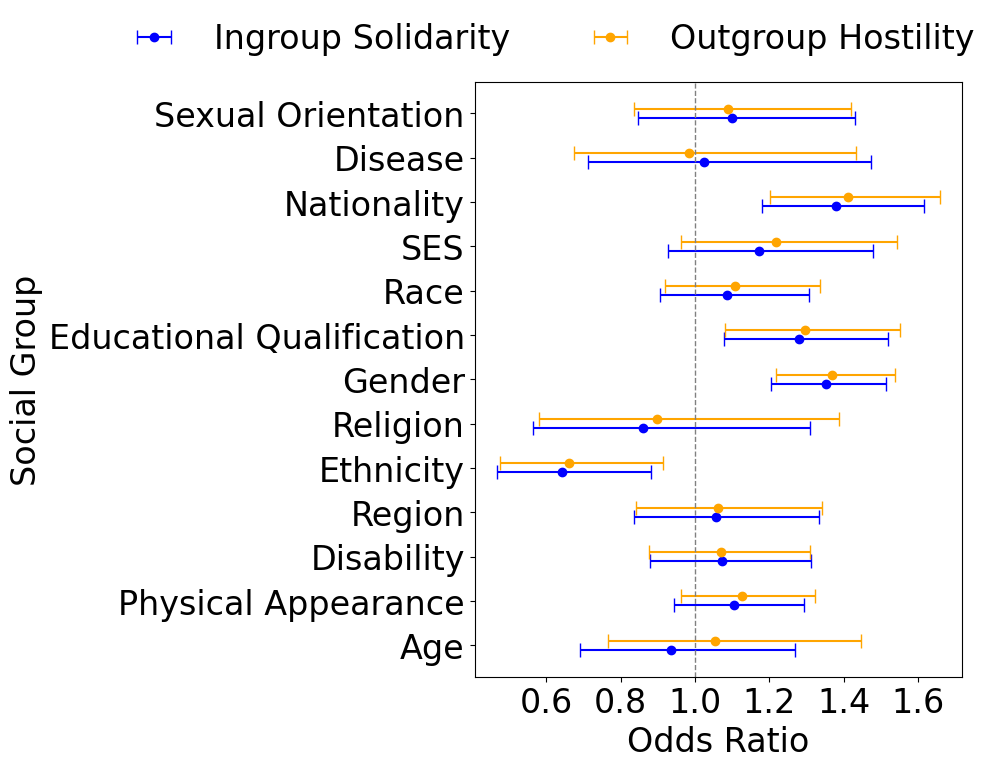

In [99]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv('./data/logistic_result_social_group.csv')

# 保留原始系数和标准误，用于计算 OR 和 95% CI
coefs = data['Coefficient']
stds = data['Std']

# 计算 OR 和 95% CI
OR = np.exp(coefs)
CI_lower = np.exp(coefs - 1.96 * stds)
CI_upper = np.exp(coefs + 1.96 * stds)

data['OR'] = OR
data['CI_lower'] = CI_lower
data['CI_upper'] = CI_upper

data = data[data['SentimentClassifier']=='aliyun']
df1 = data[data['Type']=='in']
df2 = data[data['Type']=='out']

# 只保留两个 df 都有的 SocialGroup
social_grouops1 = df1['SocialGroup'].to_list()
social_grouops2 = df2['SocialGroup'].to_list()
social_groups = list(set(social_grouops1) & set(social_grouops2))
df1 = df1[df1['SocialGroup'].isin(social_groups)]
df2 = df2[df2['SocialGroup'].isin(social_groups)]

# Odds Ratio
coef1_means = df1['OR'].to_list()
coef2_means = df2['OR'].to_list()

# 计算误差条（非对称）
coef1_err_lower = [coef1_means[i] - df1['CI_lower'].iloc[i] for i in range(len(df1))]
coef1_err_upper = [df1['CI_upper'].iloc[i] - coef1_means[i] for i in range(len(df1))]
coef1_errs = [coef1_err_lower, coef1_err_upper]

coef2_err_lower = [coef2_means[i] - df2['CI_lower'].iloc[i] for i in range(len(df2))]
coef2_err_upper = [df2['CI_upper'].iloc[i] - coef2_means[i] for i in range(len(df2))]
coef2_errs = [coef2_err_lower, coef2_err_upper]

# vertical axis position
y = np.arange(len(social_groups))
offset = 0.1  

plt.figure(figsize=(10, 8))

# plot coefficient 1 with 95% CI
plt.errorbar(coef1_means, y - offset, xerr=coef1_errs, fmt='o', capsize=5, 
             label='Ingroup Solidarity', color='blue')

# plot coefficient 2 with 95% CI
plt.errorbar(coef2_means, y + offset, xerr=coef2_errs, fmt='o', capsize=5, 
             label='Outgroup Hostility', color='orange')

# set label of vertical axis
plt.yticks(y, social_groups, fontsize=24)
plt.xticks(fontsize=24)
plt.xlabel('Odds Ratio', fontsize=24)
plt.ylabel('Social Group', fontsize=24)
plt.axvline(x=1, color='gray', linestyle='--', linewidth=1)
plt.legend(fontsize=24, loc='upper center', bbox_to_anchor=(0.15, 1.15),
           ncol=2, frameon=False)
plt.tight_layout()
plt.savefig(f'figure/logistic_result_social_group.pdf', format='pdf')
